In [2]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [3]:
# Filter for youtube only
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(right=df_youtube, how="inner", on="song_id")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

In [4]:
# Calculate song age
reference_date = datetime.now()
df_merged["age_days"] = (reference_date - df_merged["release_date"]).dt.days

# Filter for songs 90 days or more
df_mature = df_merged[df_merged["age_days"] >=90].copy()

In [6]:
# Define holidays with a 3-day window (day before, day of, day after)
# Format: (holiday_name, start_date, end_date) for each year where we have data
def get_holiday_windows(year):
    """Return dictionary of holiday windows for a given year"""
    
    holidays = {}
    
    # New Year's (Dec 30 - Jan 2)
    holidays["New Year"] = (datetime(year-1, 12, 30), datetime(year, 1, 2))
    
    # Ghana Independence Day (March 4-7)
    holidays["Independence Day (Ghana)"] = (datetime(year, 3, 4), datetime(year, 3, 7))
    
    # May Day (April 30 - May 2)
    holidays["May Day"] = (datetime(year, 4, 30), datetime(year, 5, 2))
    
    # Farmers' Day (First Friday of December) - approximate
    # For simplicity, use Dec 1-7
    holidays["Farmers' Day (Ghana)"] = (datetime(year, 12, 1), datetime(year, 12, 7))
    
    # Christmas (Dec 24-27)
    holidays["Christmas"] = (datetime(year, 12, 24), datetime(year, 12, 27))
    
    # Boxing Day (Dec 25-28)
    holidays["Boxing Day"] = (datetime(year, 12, 25), datetime(year, 12, 28))
    
    # New Year's Eve (Dec 30 - Jan 1)
    holidays["New Year's Eve"] = (datetime(year, 12, 30), datetime(year+1, 1, 1))
    
    # Easter (varies - approximate using common dates)
    # For simplicity, we'll handle Easter separately with a lookup
    easter_dates = {
        2013: (3, 29), 2014: (4, 18), 2015: (4, 3), 2016: (3, 25),
        2017: (4, 14), 2018: (4, 1), 2019: (4, 19), 2020: (4, 10),
        2021: (4, 2), 2022: (4, 15), 2023: (4, 7), 2024: (3, 29),
        2025: (4, 18), 2026: (4, 3)
    }
    
    if year in easter_dates:
        month, day = easter_dates[year]
        easter_date = datetime(year, month, day)
        holidays["Easter"] = (easter_date - timedelta(days=2), easter_date + timedelta(days=2))
    
    # Eid dates (approximate - these vary based on moon sighting)
    # For simplicity, using approximate dates
    eid_fitr_dates = {
        2013: (8, 8), 2014: (7, 28), 2015: (7, 17), 2016: (7, 6),
        2017: (6, 25), 2018: (6, 15), 2019: (6, 4), 2020: (5, 24),
        2021: (5, 13), 2022: (5, 2), 2023: (4, 21), 2024: (4, 10),
        2025: (3, 31), 2026: (3, 20)
    }
    
    if year in eid_fitr_dates:
        month, day = eid_fitr_dates[year]
        eid_date = datetime(year, month, day)
        holidays["Eid al-Fitr"] = (eid_date - timedelta(days=2), eid_date + timedelta(days=2))
    
    eid_adha_dates = {
        2013: (10, 15), 2014: (10, 4), 2015: (9, 23), 2016: (9, 12),
        2017: (9, 1), 2018: (8, 21), 2019: (8, 11), 2020: (7, 31),
        2021: (7, 20), 2022: (7, 9), 2023: (6, 28), 2024: (6, 16),
        2025: (6, 6), 2026: (5, 26)
    }
    
    if year in eid_adha_dates:
        month, day = eid_adha_dates[year]
        eid_date = datetime(year, month, day)
        holidays["Eid al-Adha"] = (eid_date - timedelta(days=2), eid_date + timedelta(days=2))
    
    return holidays


In [7]:
# Flag Holiday Releases
def is_holiday_release(release_date):
    """Check if a release date falls within any holiday window"""
    if pd.isna(release_date):
        return False, None
    
    year = release_date.year
    
    # Get holidays for that year
    holiday_windows = get_holiday_windows(year)
    
    for holiday_name, (start_date, end_date) in holiday_windows.items():
        if start_date <= release_date <= end_date:
            return True, holiday_name
    
    return False, None

# Apply the function to flag holiday releases
df_mature['is_holiday_release'], df_mature['holiday_name'] = zip(
    *df_mature['release_date'].apply(is_holiday_release)
)

In [8]:
# Compare Performance
# Calculate average views for holiday vs regular releases
holiday_performance = df_mature[df_mature['is_holiday_release']]['views'].mean()
regular_performance = df_mature[~df_mature['is_holiday_release']]['views'].mean()

# Calculate median for robustness
holiday_median = df_mature[df_mature['is_holiday_release']]['views'].median()
regular_median = df_mature[~df_mature['is_holiday_release']]['views'].median()

# Calculate performance difference
difference = holiday_performance - regular_performance
percent_difference = (difference / regular_performance) * 100

In [9]:
# Performance by Specific Holiday
# Group by specific holiday name
holiday_specific = df_mature[df_mature['is_holiday_release']].groupby('holiday_name')['views'].agg(['mean', 'median', 'count']).round(0)
holiday_specific = holiday_specific.sort_values('mean', ascending=False)

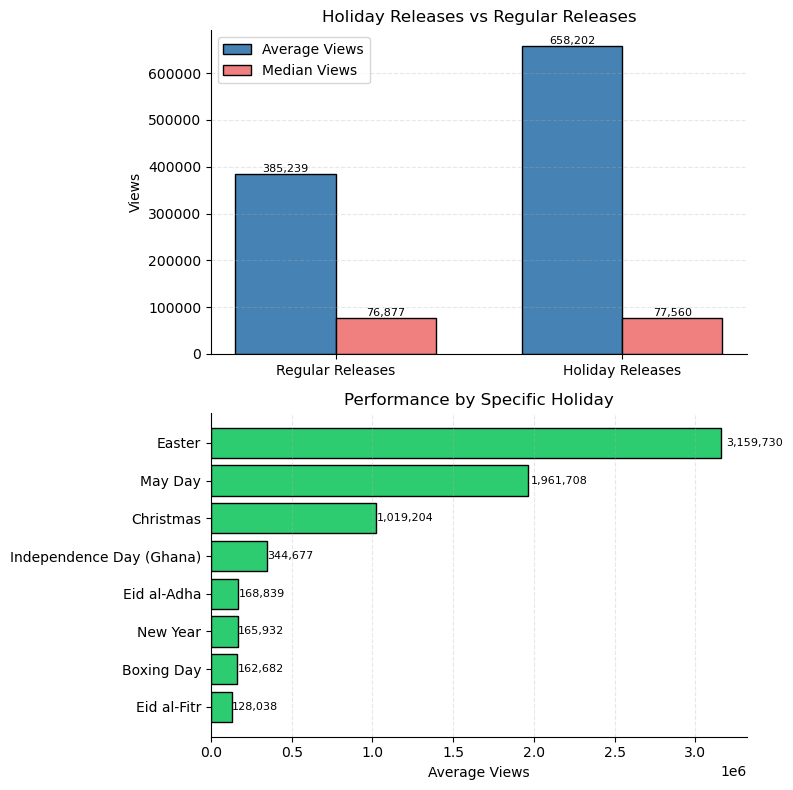

In [32]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Plot 1: Bar chart comparing holiday vs regular releases
ax1 = axes[0]
categories = ['Regular Releases', 'Holiday Releases']
means = [regular_performance, holiday_performance]
medians = [regular_median, holiday_median]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, means, width, label='Average Views', color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, medians, width, label='Median Views', color='lightcoral', edgecolor='black')

ax1.set_ylabel('Views')
ax1.set_title('Holiday Releases vs Regular Releases')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.set_yscale('linear')
ax1.spines['right'].set_visible(False)  # Despine - remove right and top spines 
ax1.spines['top'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
ax1.legend(loc='upper left')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Performance by specific holiday
ax2 = axes[1]
if len(holiday_specific) > 0:
    top_holidays = holiday_specific.head(8).copy()
    bars = ax2.barh(range(len(top_holidays)), top_holidays['mean'], color='#2ecc71', edgecolor='black')
    ax2.set_yticks(range(len(top_holidays)))
    ax2.set_yticklabels(top_holidays.index)
    ax2.set_xlabel('Average Views')
    ax2.set_title('Performance by Specific Holiday')
    ax2.invert_yaxis()  # Best day at top
    ax2.spines['top'].set_visible(False)    # Despine - remove right and top spines 
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, top_holidays['mean']):
        ax2.text(val + val*0.01, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Insufficient holiday data', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Performance by Specific Holiday')

plt.tight_layout()


Insights:
- Holiday releases significantly outperform regular releases – Holiday releases average 658,202 views compared to 385,239 for regular releases, a 71% increase in average views
- Easter is by far the most powerful holiday – With 3,159,730 average views, Easter outperforms every other holiday by a massive margin (over 2 million views ahead of second place)
- May Day and Christmas are the next best options – Both generate over 1 million average views, making them strong secondary holiday release windows

Recommendations
- Prioritize Easter weekend for major releases – The data shows Easter is uniquely powerful; schedule album launches or biggest singles for this window
- Use May Day (May 1) and Christmas as secondary holiday targets – Both generate strong performance and can work for important but non-flagship releases
- Avoid Eid holidays and New Year for releases – With average views under 170,000, these holidays show no performance benefit over regular release days; don't rush to meet these deadlines